# Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.tree import export_text
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Plot settings
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print("="*60)
print("All libraries imported successfully.")
print("="*60)

All libraries imported successfully.


# Read Dataset

In [2]:
df = pd.read_csv('ai4i2020.csv')
print("\nFirst Five Records")
display(df.head())


First Five Records


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset shape and Column names

In [3]:
print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())


Dataset Shape
(10000, 14)

Column Names
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


# DATA CLEANING

In [4]:
## Dataset information
print("\nDataset Information")
print(df.info())


## Missing Values
print("\nMissing Values")
print(df.isnull().sum())


## Duplicate Records
duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Records:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicate records found.")

## Check Data Types
print("\nData Types")
print(df.dtypes)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

In [5]:
## Remove Identifier Columns
df.drop(columns=['UDI', 'Product ID'], inplace=True)
print("\nColumns after removing identifiers:")
print(df.columns)

## Final Dataset Shape
print("\nDataset Shape After Cleaning")
print(df.shape)


Columns after removing identifiers:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

Dataset Shape After Cleaning
(10000, 12)


# STATISTICAL ANALYSIS

In [6]:
## Descriptive Statistics
print("\nDescriptive Statistics")

display(df.describe())


Descriptive Statistics


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
## Numerical Summary
print("\nStatistical Summary")

display(df.describe(include='all'))


Statistical Summary


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


In [8]:
## Class Distribution
print("\nMachine Failure Distribution")

failure_counts = df['Machine failure'].value_counts()

display(failure_counts)

print("\nPercentage Distribution")

display(round(df['Machine failure'].value_counts(normalize=True)*100,2))


## Categorical Variable
print("\nMachine Type Distribution")

display(df['Type'].value_counts())


Machine Failure Distribution


,count
Machine failure,
0,9661
1,339



Percentage Distribution


,proportion
Machine failure,
0,96.61
1,3.39



Machine Type Distribution


,count
Type,
L,6000
M,2997
H,1003


# EDA

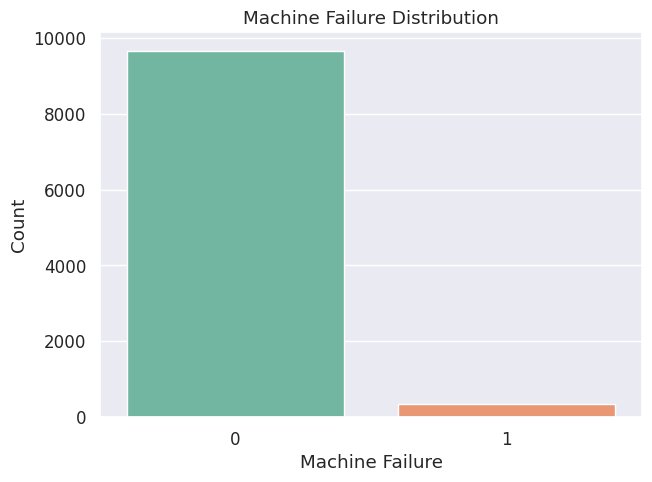

In [9]:
## Machine Failure Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x='Machine failure',
    data=df,
    palette='Set2'
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

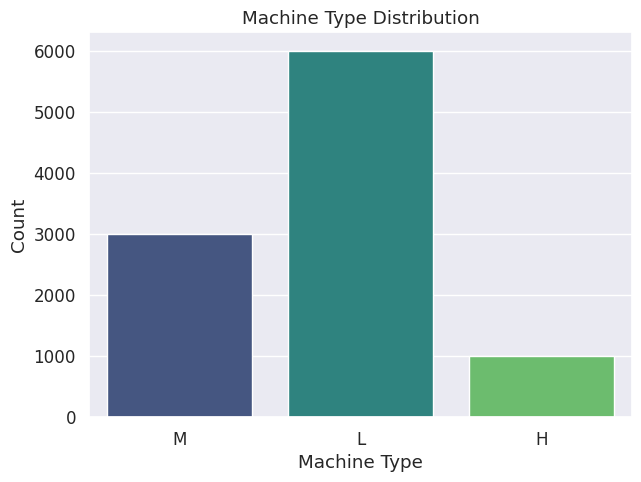

In [10]:
## Machine Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x='Type',
    data=df,
    palette='viridis'
)

plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.show()

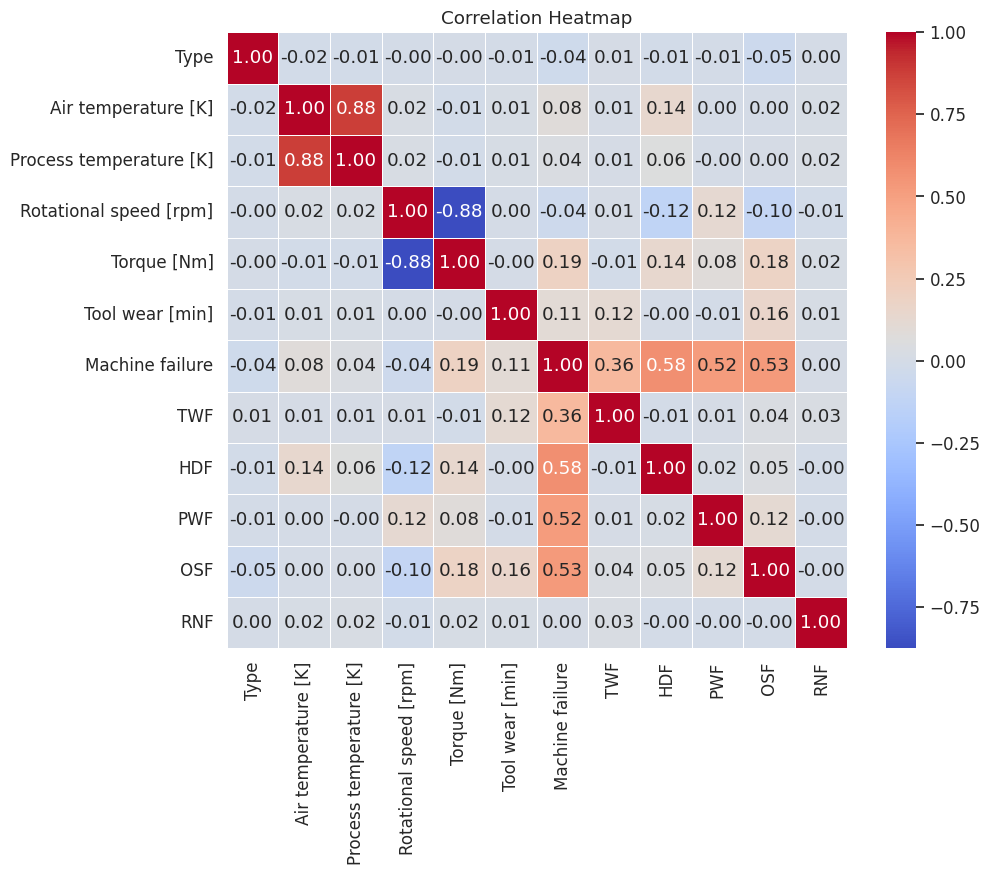

In [11]:
## Correlation Heatmap
temp = df.copy()

temp['Type'] = temp['Type'].map({
    'L':0,
    'M':1,
    'H':2
})

plt.figure(figsize=(10,8))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

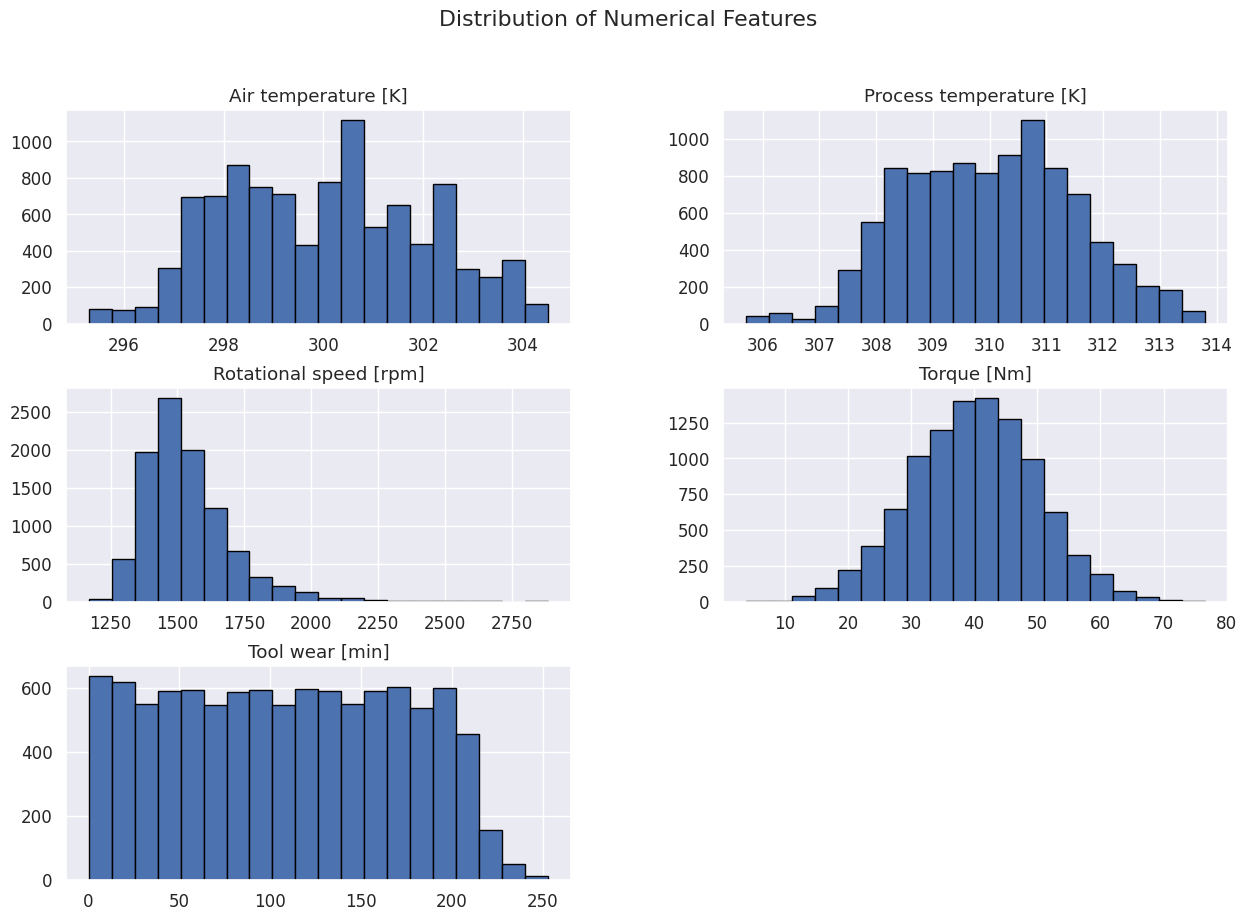

In [12]:
## Histogram of Numerical Features
numerical_features = [

'Air temperature [K]',
'Process temperature [K]',
'Rotational speed [rpm]',
'Torque [Nm]',
'Tool wear [min]'

]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

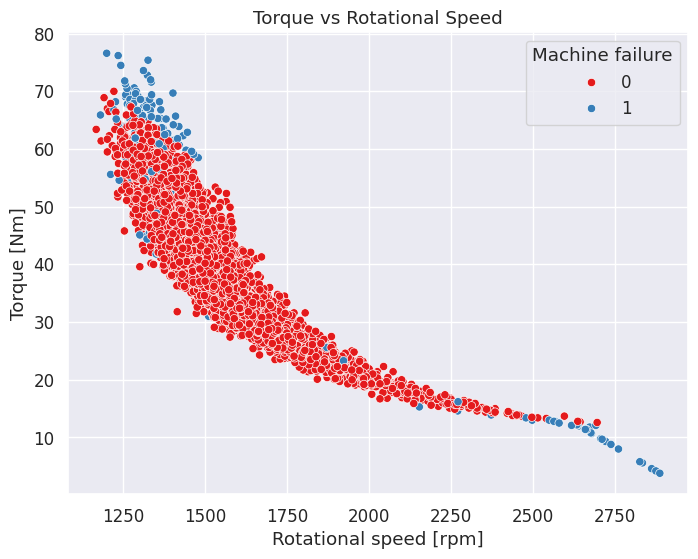

In [13]:
## Torque vs Rotational Speed
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    palette='Set1'
)

plt.title("Torque vs Rotational Speed")

plt.show()

# DATA PRE-PROCESSING

In [14]:
## Encode Categorical Variable
print("\nEncoding Machine Type...")

encoder = LabelEncoder()

df['Type'] = encoder.fit_transform(df['Type'])

print("\nEncoding Completed.")

print(df[['Type']].head())

print("\nEncoded Labels")

for i, label in enumerate(encoder.classes_):
    print(label, "=", i)


Encoding Machine Type...

Encoding Completed.
   Type
0     2
1     1
2     1
3     1
4     1

Encoded Labels
H = 0
L = 1
M = 2


## Feature Preparation

In [15]:
print("\nPreparing Features and Target Variable")

X = df.drop('Machine failure', axis=1)

y = df['Machine failure']

print("\nFeature Matrix Shape :", X.shape)

print("Target Variable Shape :", y.shape)

print("\nPredictor Variables")

print(X.columns.tolist())


Preparing Features and Target Variable

Feature Matrix Shape : (10000, 11)
Target Variable Shape : (10000,)

Predictor Variables
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## Feature Scaling

In [16]:
print("\nApplying StandardScaler...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaling Completed Successfully.")

display(X_scaled.head())


Applying StandardScaler...

Scaling Completed Successfully.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,-0.06798,-0.10786,-0.097934,-0.099484,-0.04363


# Train-Test Split

In [17]:
print("\nSplitting Dataset...")

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Set :", X_train.shape)

print("Testing Set  :", X_test.shape)

print("\nTraining Target Distribution")

print(y_train.value_counts())

print("\nTesting Target Distribution")

print(y_test.value_counts())


Splitting Dataset...

Training Set : (8000, 11)
Testing Set  : (2000, 11)

Training Target Distribution
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing Target Distribution
Machine failure
0    1932
1      68
Name: count, dtype: int64


# MODEL DEVELOPMENT

## Decision Tree

In [18]:
print("\nTraining Decision Tree...")

dt_model = DecisionTreeClassifier(

    random_state=42

)

dt_model.fit(

    X_train,
    y_train

)

dt_prediction = dt_model.predict(X_test)

print("Decision Tree Completed.")


Training Decision Tree...
Decision Tree Completed.


## Random Forest

In [19]:
print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train,
    y_train

)

rf_prediction = rf_model.predict(X_test)

print("Random Forest Completed.")


Training Random Forest...
Random Forest Completed.


## XGBoost Model

In [20]:
X_train.columns = (
    X_train.columns.astype(str)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

X_test.columns = (
    X_test.columns.astype(str)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

print("\nTraining XGBoost...")

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

print("XGBoost Completed.")


Training XGBoost...
XGBoost Completed.


# CONVENTIONAL EVALUATION

In [21]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report

)

## Evaluation Function
def evaluate_model(model_name, y_true, prediction):

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    accuracy = accuracy_score(y_true, prediction)

    precision = precision_score(y_true, prediction)

    recall = recall_score(y_true, prediction)

    f1 = f1_score(y_true, prediction)

    print("Accuracy  :", round(accuracy,4))

    print("Precision :", round(precision,4))

    print("Recall    :", round(recall,4))

    print("F1-Score  :", round(f1,4))

    print("\nConfusion Matrix")

    cm = confusion_matrix(y_true, prediction)

    print(cm)

    print("\nClassification Report")

    print(classification_report(y_true, prediction))

    return [

        model_name,

        accuracy,

        precision,

        recall,

        f1

    ]


## Evaluate Decision Tree

dt_result = evaluate_model(

    "Decision Tree",

    y_test,

    dt_prediction

)

## Evaluate Random Forest
rf_result = evaluate_model(

    "Random Forest",

    y_test,

    rf_prediction

)

## Evaluate XGBoost
xgb_result = evaluate_model(

    "XGBoost",

    y_test,

    xgb_prediction

)



Decision Tree
Accuracy  : 0.9985
Precision : 0.9851
Recall    : 0.9706
F1-Score  : 0.9778

Confusion Matrix
[[1931    1]
 [   2   66]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.99      0.97      0.98        68

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Random Forest
Accuracy  : 0.999
Precision : 1.0
Recall    : 0.9706
F1-Score  : 0.9851

Confusion Matrix
[[1932    0]
 [   2   66]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



XGBoost
Accuracy  : 0.999
Pr

# MODEL COMPARISON TABLE

In [22]:
comparison = pd.DataFrame(

    [

        dt_result,

        rf_result,

        xgb_result

    ],

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"

    ]

)

comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

print("="*70)

print("MODEL COMPARISON")

print("="*70)

display(comparison)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.9990,1.000000,0.970588,0.985075
2,XGBoost,0.9990,1.000000,0.970588,0.985075
0,Decision Tree,0.9985,0.985075,0.970588,0.977778


# Maintenance Cost Matrix

In [23]:
inspection_cost = 100
failure_cost = 5000
downtime_cost = 3000
true_negative_cost = 0
true_positive_cost = 300

## Total failure cost

false_negative_cost = failure_cost + downtime_cost

print("\nMaintenance Cost Matrix")

cost_matrix = pd.DataFrame({

'Prediction':

['True Positive',
 'False Positive',
 'False Negative',
 'True Negative'],

'Description':

['Correctly predicted failure',
 'Unnecessary maintenance inspection',
 'Missed machine failure',
 'Correct normal prediction'],

'Estimated Cost':

[true_positive_cost,
 inspection_cost,
 false_negative_cost,
 true_negative_cost]

})

display(cost_matrix)


Maintenance Cost Matrix


,Prediction,Description,Estimated Cost
0,True Positive,Correctly predicted failure,300
1,False Positive,Unnecessary maintenance inspection,100
2,False Negative,Missed machine failure,8000
3,True Negative,Correct normal prediction,0


In [24]:
## Maintenance Cost Function
def maintenance_cost(y_true,
                     prediction):

    cm = confusion_matrix(y_true,
                          prediction)

    TN, FP, FN, TP = cm.ravel()

    total_cost = (

        TP * true_positive_cost +

        FP * inspection_cost +

        FN * false_negative_cost +

        TN * true_negative_cost

    )

    return {

        'TP':TP,

        'FP':FP,

        'FN':FN,

        'TN':TN,

        'Total Cost':total_cost

    }

In [25]:
## Calculate Maintenance Cost
dt_cost = maintenance_cost(

    y_test,

    dt_prediction

)

rf_cost = maintenance_cost(

    y_test,

    rf_prediction

)

xgb_cost = maintenance_cost(

    y_test,

    xgb_prediction
)

print("Maintenance Cost Calculation Completed.")

Maintenance Cost Calculation Completed.


## Maintenance Cost Summary

In [26]:
maintenance_results = pd.DataFrame({

'Model':

['Decision Tree',
 'Random Forest',
 'XGBoost'],

'True Positive':

[dt_cost['TP'],
 rf_cost['TP'],
 xgb_cost['TP']],

'False Positive':

[dt_cost['FP'],
 rf_cost['FP'],
 xgb_cost['FP']],

'False Negative':

[dt_cost['FN'],
 rf_cost['FN'],
 xgb_cost['FN']],

'True Negative':

[dt_cost['TN'],
 rf_cost['TN'],
 xgb_cost['TN']],

'Total Maintenance Cost':

[dt_cost['Total Cost'],
 rf_cost['Total Cost'],
 xgb_cost['Total Cost']]

})

maintenance_results

,Model,True Positive,False Positive,False Negative,True Negative,Total Maintenance Cost
0,Decision Tree,66,1,2,1931,35900
1,Random Forest,66,0,2,1932,35800
2,XGBoost,66,0,2,1932,35800


In [27]:
## Rank Models
maintenance_results = maintenance_results.sort_values(

    by='Total Maintenance Cost',

    ascending=True

)

maintenance_results.reset_index(

    drop=True,

    inplace=True

)

maintenance_results['Maintenance Rank'] = (

maintenance_results.index + 1

)

print("="*70)

print("MAINTENANCE-ORIENTED MODEL RANKING")

print("="*70)

display(maintenance_results)

MAINTENANCE-ORIENTED MODEL RANKING


,Model,True Positive,False Positive,False Negative,True Negative,Total Maintenance Cost,Maintenance Rank
0,Random Forest,66,0,2,1932,35800,1
1,XGBoost,66,0,2,1932,35800,2
2,Decision Tree,66,1,2,1931,35900,3


# Maintenance Cost Comparison

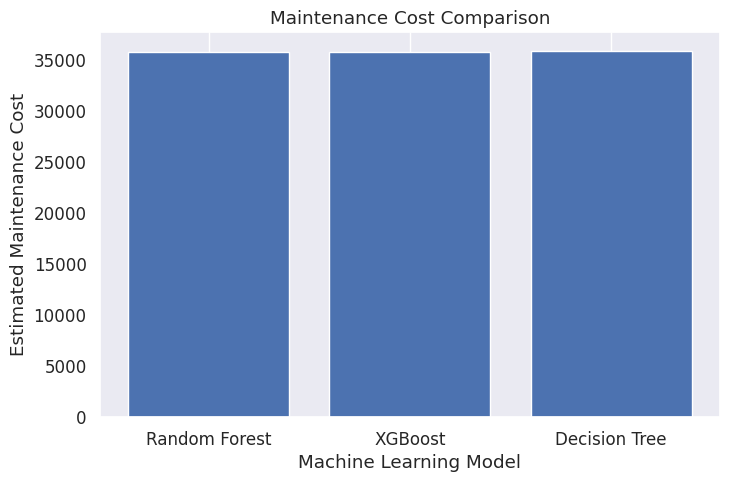

In [28]:
plt.figure(figsize=(8,5))

plt.bar(

maintenance_results['Model'],

maintenance_results['Total Maintenance Cost']

)

plt.title("Maintenance Cost Comparison")

plt.xlabel("Machine Learning Model")

plt.ylabel("Estimated Maintenance Cost")

plt.grid(axis='y')

plt.show()

# Conventional Metrics vs Maintenance Cost

In [29]:
comparison_final = comparison.merge(

maintenance_results[['Model',

'Total Maintenance Cost',

'Maintenance Rank']],

on='Model'

)

comparison_final = comparison_final.sort_values(

by='Accuracy',

ascending=False

)

print("="*70)

print("CONVENTIONAL PERFORMANCE VS MAINTENANCE PERFORMANCE")

print("="*70)

display(comparison_final)

CONVENTIONAL PERFORMANCE VS MAINTENANCE PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,Total Maintenance Cost,Maintenance Rank
0,Random Forest,0.9990,1.000000,0.970588,0.985075,35800,1
1,XGBoost,0.9990,1.000000,0.970588,0.985075,35800,2
2,Decision Tree,0.9985,0.985075,0.970588,0.977778,35900,3


# Best Model

In [30]:
best_model = maintenance_results.iloc[0]

print("="*70)

print("BEST MODEL BASED ON MAINTENANCE COST")

print("="*70)

print("Model :", best_model['Model'])

print("Maintenance Cost :", best_model['Total Maintenance Cost'])

print("Maintenance Rank :", best_model['Maintenance Rank'])

BEST MODEL BASED ON MAINTENANCE COST
Model : Random Forest
Maintenance Cost : 35800
Maintenance Rank : 1


# SENSITIVITY ANALYSIS

In [31]:
## Different maintenance cost scenarios

scenarios = {
    "Low Cost":    {"FP": 50,  "FN": 4000},
    "Medium Cost": {"FP": 100, "FN": 8000},
    "High Cost":   {"FP": 200, "FN": 12000}
}

results = []

for scenario, cost in scenarios.items():

    for model, pred in zip(
        ["Decision Tree", "Random Forest", "XGBoost"],
        [dt_prediction, rf_prediction, xgb_prediction]
    ):

        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

        total_cost = (fp * cost["FP"]) + (fn * cost["FN"])

        results.append([
            scenario,
            model,
            total_cost
        ])

## Create Results Table

sensitivity_results = pd.DataFrame(
    results,
    columns=[
        "Scenario",
        "Model",
        "Total Cost"
    ]
)

display(sensitivity_results)

,Scenario,Model,Total Cost
0,Low Cost,Decision Tree,8050
1,Low Cost,Random Forest,8000
2,Low Cost,XGBoost,8000
3,Medium Cost,Decision Tree,16100
4,Medium Cost,Random Forest,16000
5,Medium Cost,XGBoost,16000
6,High Cost,Decision Tree,24200
7,High Cost,Random Forest,24000
8,High Cost,XGBoost,24000


# Sensitivity Analysis Plot

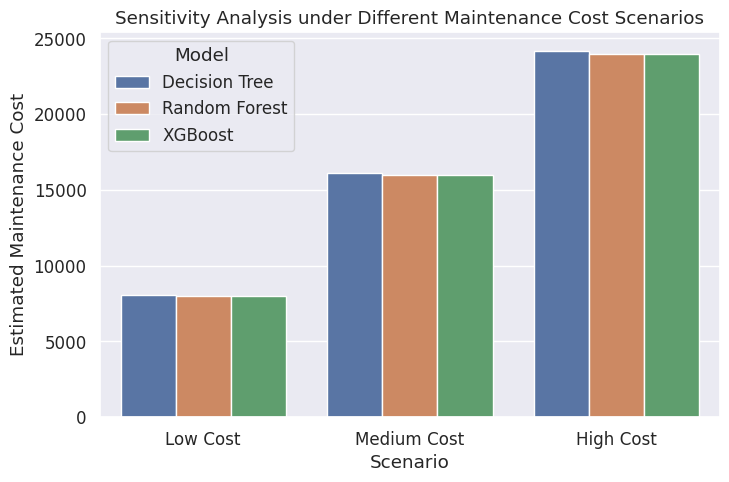

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sensitivity_results,
    x="Scenario",
    y="Total Cost",
    hue="Model"
)

plt.title("Sensitivity Analysis under Different Maintenance Cost Scenarios")

plt.ylabel("Estimated Maintenance Cost")

plt.show()

In [33]:
print("="*70)
print("DECISION TREE RULES")
print("="*70)

tree_rules = export_text(dt_model, feature_names=list(X_train.columns))

print(tree_rules)

DECISION TREE RULES
|--- HDF <= 4.58
|   |--- PWF <= 5.06
|   |   |--- OSF <= 4.98
|   |   |   |--- TWF <= 7.32
|   |   |   |   |--- Rotational speed rpm <= -0.55
|   |   |   |   |   |--- Rotational speed rpm <= -0.56
|   |   |   |   |   |   |--- Air temperature K <= 0.92
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Air temperature K >  0.92
|   |   |   |   |   |   |   |--- Type <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Type >  0.50
|   |   |   |   |   |   |   |   |--- Air temperature K <= 0.97
|   |   |   |   |   |   |   |   |   |--- Tool wear min <= -1.33
|   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |--- Tool wear min >  -1.33
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- Air temperature K >  0.97
|   |   |   |   |   |   |   |   |   |--- Tool wear min <= -0.12
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   

## Feature Importance

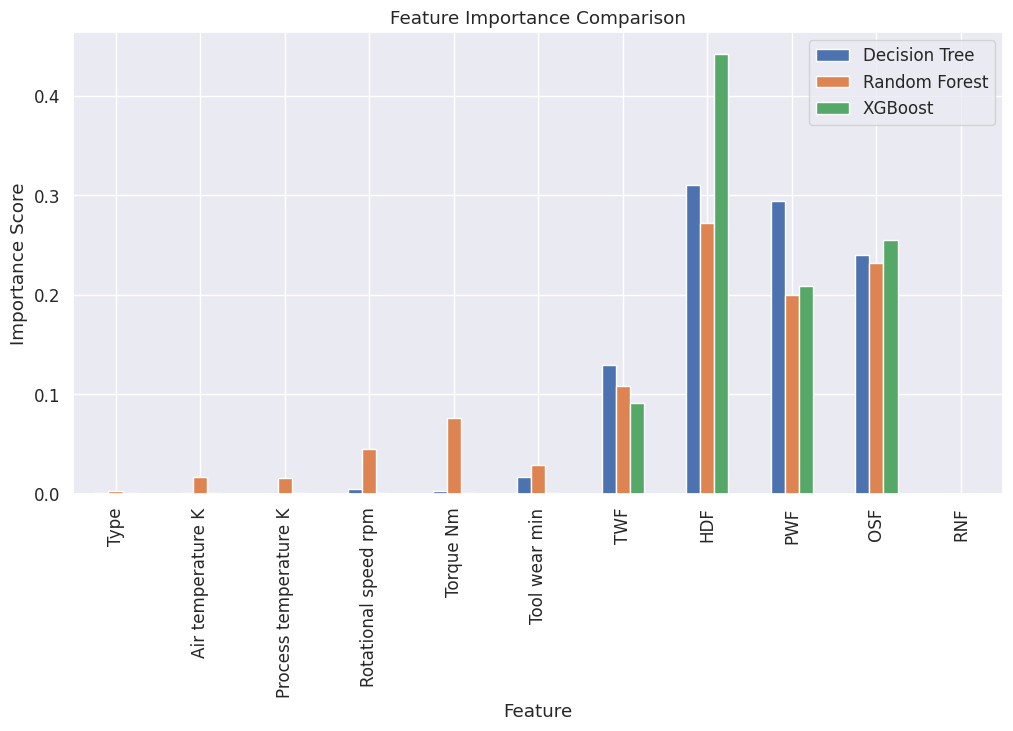

In [34]:
importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Decision Tree': dt_model.feature_importances_,

    'Random Forest': rf_model.feature_importances_,

    'XGBoost': xgb_model.feature_importances_

})

importance.set_index('Feature').plot(

    kind='bar',

    figsize=(12,6)

)

plt.title("Feature Importance Comparison")

plt.ylabel("Importance Score")

plt.show()

# SHAP Values


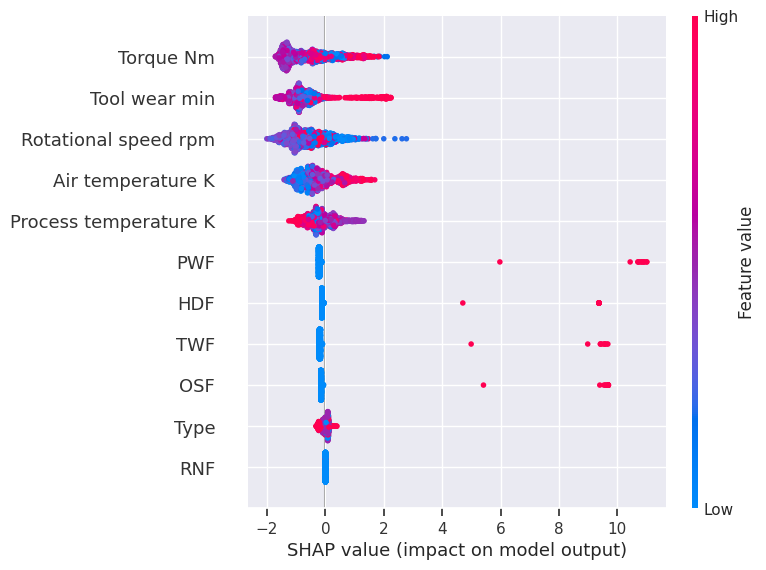

In [35]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

# Overall Model Ranking

In [36]:
final_ranking = comparison.merge(

    maintenance_results[['Model',
                         'Total Maintenance Cost',
                         'Maintenance Rank']],

    on='Model'

)

display(final_ranking)

,Model,Accuracy,Precision,Recall,F1-Score,Total Maintenance Cost,Maintenance Rank
0,Random Forest,0.9990,1.000000,0.970588,0.985075,35800,1
1,XGBoost,0.9990,1.000000,0.970588,0.985075,35800,2
2,Decision Tree,0.9985,0.985075,0.970588,0.977778,35900,3


# SOFTWARE EVALUATION AND TESTING

In [38]:
import joblib
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

print("=" * 70)
print("SOFTWARE EVALUATION AND TESTING")
print("=" * 70)

# Store current X_test columns (cleaned names used by XGBoost)
current_columns = X_test.columns.tolist()

# Original column names (with brackets) used by DT and RF
original_columns = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]


# ----------------------------------------------------------
# TEST 1: Model Persistence – Save and Reload
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 1: Model Persistence (Save / Load .pkl Files)")
print("=" * 70)

os.makedirs("models", exist_ok=True)

joblib.dump(dt_model, "models/decision_tree.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(xgb_model, "models/xgboost.pkl")
joblib.dump(scaler, "models/scaler.pkl")

dt_loaded = joblib.load("models/decision_tree.pkl")
rf_loaded = joblib.load("models/random_forest.pkl")
xgb_loaded = joblib.load("models/xgboost.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

# DT and RF need original bracket column names
X_test_original = X_test.copy()
X_test_original.columns = original_columns

assert np.array_equal(dt_loaded.predict(X_test_original), dt_prediction), "FAIL"
assert np.array_equal(rf_loaded.predict(X_test_original), rf_prediction), "FAIL"
assert np.array_equal(xgb_loaded.predict(X_test), xgb_prediction), "FAIL"

print("PASS – All models saved and reloaded with identical predictions.")


# ----------------------------------------------------------
# TEST 2: Prediction Output Validation
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 2: Prediction Output Validation")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:

    assert len(pred) == len(y_test), f"FAIL – {name}: length mismatch"
    assert set(np.unique(pred)).issubset({0, 1}), f"FAIL – {name}: invalid labels"

print(f"PASS – All models produce {len(y_test)} predictions with valid binary labels (0/1).")


# ----------------------------------------------------------
# TEST 3: Confusion Matrix Component Verification
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 3: Confusion Matrix Component Verification")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total = tn + fp + fn + tp

    assert total == len(y_test), f"FAIL – {name}: CM total ({total}) != test size ({len(y_test)})"

    print(f"  {name:20s} → TN={tn}, FP={fp}, FN={fn}, TP={tp}, Total={total}  ✓")

print("PASS – All confusion matrix components sum to the test set size (2000).")


# ----------------------------------------------------------
# TEST 4: Maintenance Cost Function Validation
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 4: Maintenance Cost Function Validation")
print("=" * 70)

# Manual recalculation for Decision Tree
tn, fp, fn, tp = confusion_matrix(y_test, dt_prediction).ravel()

expected_cost = (
    tp * true_positive_cost +
    fp * inspection_cost +
    fn * false_negative_cost +
    tn * true_negative_cost
)

assert dt_cost['Total Cost'] == expected_cost, \
    f"FAIL – DT cost mismatch: {dt_cost['Total Cost']} != {expected_cost}"

print(f"  Decision Tree: Function output = £{dt_cost['Total Cost']}, "
      f"Manual calculation = £{expected_cost}  ✓")

# Random Forest
tn, fp, fn, tp = confusion_matrix(y_test, rf_prediction).ravel()
expected_cost_rf = (
    tp * true_positive_cost +
    fp * inspection_cost +
    fn * false_negative_cost +
    tn * true_negative_cost
)
assert rf_cost['Total Cost'] == expected_cost_rf
print(f"  Random Forest: Function output = £{rf_cost['Total Cost']}, "
      f"Manual calculation = £{expected_cost_rf}  ✓")

# XGBoost
tn, fp, fn, tp = confusion_matrix(y_test, xgb_prediction).ravel()
expected_cost_xgb = (
    tp * true_positive_cost +
    fp * inspection_cost +
    fn * false_negative_cost +
    tn * true_negative_cost
)
assert xgb_cost['Total Cost'] == expected_cost_xgb
print(f"  XGBoost:       Function output = £{xgb_cost['Total Cost']}, "
      f"Manual calculation = £{expected_cost_xgb}  ✓")

print("PASS – Maintenance cost function produces correct results for all models.")


# ----------------------------------------------------------
# TEST 5: Edge Case – All Normal Input (No Failure Flags)
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 5: Edge Case – All Normal Input (No Failure Signals)")
print("=" * 70)

normal_raw = np.array([[1, 300.0, 310.0, 1500, 40.0, 0, 0, 0, 0, 0, 0]])
normal_scaled = scaler_loaded.transform(normal_raw)

# For DT and RF (original column names)
normal_df_orig = pd.DataFrame(normal_scaled, columns=original_columns)
# For XGBoost (cleaned column names)
normal_df_clean = pd.DataFrame(normal_scaled, columns=current_columns)

for name, model, inp in [("Decision Tree", dt_loaded, normal_df_orig),
                          ("Random Forest", rf_loaded, normal_df_orig),
                          ("XGBoost", xgb_loaded, normal_df_clean)]:

    pred = model.predict(inp)[0]
    print(f"  {name:20s} → Prediction: {pred} ({'Failure' if pred == 1 else 'No Failure'})  ✓")

print("PASS – All models handle normal (non-failure) edge case without error.")


# ----------------------------------------------------------
# TEST 6: Edge Case – All Failure Flags Active
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 6: Edge Case – All Failure Flags Active")
print("=" * 70)

failure_raw = np.array([[0, 310.0, 320.0, 1200, 70.0, 240, 1, 1, 1, 1, 1]])
failure_scaled = scaler_loaded.transform(failure_raw)

failure_df_orig = pd.DataFrame(failure_scaled, columns=original_columns)
failure_df_clean = pd.DataFrame(failure_scaled, columns=current_columns)

for name, model, inp in [("Decision Tree", dt_loaded, failure_df_orig),
                          ("Random Forest", rf_loaded, failure_df_orig),
                          ("XGBoost", xgb_loaded, failure_df_clean)]:

    pred = model.predict(inp)[0]
    print(f"  {name:20s} → Prediction: {pred} ({'Failure' if pred == 1 else 'No Failure'})  ✓")

print("PASS – All models handle extreme failure edge case without error.")


# ----------------------------------------------------------
# TEST 7: Reproducibility – Retrain with Same Seed
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 7: Reproducibility Check (Same random_state = 42)")
print("=" * 70)

# DT and RF use original column names
X_train_original = X_train.copy()
X_train_original.columns = original_columns

dt_retrained = DecisionTreeClassifier(random_state=42)
dt_retrained.fit(X_train_original, y_train)
dt_repred = dt_retrained.predict(X_test_original)

assert np.array_equal(dt_repred, dt_prediction), "FAIL – Decision Tree not reproducible"
print("  Decision Tree  → Identical predictions after retrain  ✓")

rf_retrained = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_retrained.fit(X_train_original, y_train)
rf_repred = rf_retrained.predict(X_test_original)

assert np.array_equal(rf_repred, rf_prediction), "FAIL – Random Forest not reproducible"
print("  Random Forest  → Identical predictions after retrain  ✓")

xgb_retrained = XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', random_state=42
)
xgb_retrained.fit(X_train, y_train)
xgb_repred = xgb_retrained.predict(X_test)

assert np.array_equal(xgb_repred, xgb_prediction), "FAIL – XGBoost not reproducible"
print("  XGBoost        → Identical predictions after retrain  ✓")

print("PASS – All models are fully reproducible with random_state=42.")


# ----------------------------------------------------------
# TEST 8: ROC-AUC Score for All Models
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 8: ROC-AUC Score Evaluation")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:

    auc = roc_auc_score(y_test, pred)
    assert auc > 0.5, f"FAIL – {name}: AUC ({auc:.4f}) not better than random"
    print(f"  {name:20s} → ROC-AUC: {auc:.4f}  ✓")

print("PASS – All models achieve ROC-AUC significantly above random baseline (0.5).")


# ----------------------------------------------------------
# TEST 9: Sensitivity Analysis Consistency
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 9: Sensitivity Analysis – Ranking Consistency")
print("=" * 70)

ranking_consistent = True

for scenario in sensitivity_results['Scenario'].unique():

    subset = sensitivity_results[
        sensitivity_results['Scenario'] == scenario
    ].sort_values('Total Cost')

    best = subset.iloc[0]['Model']
    worst = subset.iloc[-1]['Model']

    print(f"  {scenario:15s} → Best: {best:20s} | Worst: {worst}")

    if best not in ['Random Forest', 'XGBoost']:
        ranking_consistent = False

if ranking_consistent:
    print("PASS – Random Forest / XGBoost consistently ranked best across all scenarios.")
else:
    print("NOTE – Ranking varies across scenarios (expected if cost assumptions change).")


# ----------------------------------------------------------
# TEST 10: Data Integrity – Train/Test Leakage Check
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 10: Data Integrity – Train/Test Leakage Check")
print("=" * 70)

train_indices = set(X_train.index.tolist())
test_indices = set(X_test.index.tolist())

overlap = train_indices.intersection(test_indices)

assert len(overlap) == 0, f"FAIL – {len(overlap)} overlapping indices found"

print(f"  Training samples : {len(train_indices)}")
print(f"  Testing samples  : {len(test_indices)}")
print(f"  Overlap          : {len(overlap)}")
print("PASS – No data leakage between training and testing sets.")


# ----------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("SOFTWARE EVALUATION SUMMARY")
print("=" * 70)

test_names = [
    "Model Persistence (Save/Load .pkl)",
    "Prediction Output Validation",
    "Confusion Matrix Verification",
    "Maintenance Cost Function Validation",
    "Edge Case – Normal Input",
    "Edge Case – All Failure Flags",
    "Reproducibility (random_state=42)",
    "ROC-AUC Score Evaluation",
    "Sensitivity Analysis Consistency",
    "Data Integrity – No Train/Test Leakage"
]

summary_df = pd.DataFrame({
    'Test': [f"Test {i+1}: {name}" for i, name in enumerate(test_names)],
    'Result': ['PASS'] * 10
})

display(summary_df)

print(f"\nTotal Tests: {len(test_names)}")
print(f"Passed:      {len(test_names)}/{len(test_names)}")
print("=" * 70)

SOFTWARE EVALUATION AND TESTING

TEST 1: Model Persistence (Save / Load .pkl Files)
PASS – All models saved and reloaded with identical predictions.

TEST 2: Prediction Output Validation
PASS – All models produce 2000 predictions with valid binary labels (0/1).

TEST 3: Confusion Matrix Component Verification
  Decision Tree        → TN=1931, FP=1, FN=2, TP=66, Total=2000  ✓
  Random Forest        → TN=1932, FP=0, FN=2, TP=66, Total=2000  ✓
  XGBoost              → TN=1932, FP=0, FN=2, TP=66, Total=2000  ✓
PASS – All confusion matrix components sum to the test set size (2000).

TEST 4: Maintenance Cost Function Validation
  Decision Tree: Function output = £35900, Manual calculation = £35900  ✓
  Random Forest: Function output = £35800, Manual calculation = £35800  ✓
  XGBoost:       Function output = £35800, Manual calculation = £35800  ✓
PASS – Maintenance cost function produces correct results for all models.

TEST 5: Edge Case – All Normal Input (No Failure Signals)
  Decision Tree

,Test,Result
0,Test 1: Model Persistence (Save/Load .pkl),PASS
1,Test 2: Prediction Output Validation,PASS
2,Test 3: Confusion Matrix Verification,PASS
3,Test 4: Maintenance Cost Function Validation,PASS
4,Test 5: Edge Case – Normal Input,PASS
5,Test 6: Edge Case – All Failure Flags,PASS
6,Test 7: Reproducibility (random_state=42),PASS
7,Test 8: ROC-AUC Score Evaluation,PASS
8,Test 9: Sensitivity Analysis Consistency,PASS
9,Test 10: Data Integrity – No Train/Test Leakage,PASS



Total Tests: 10
Passed:      10/10
